# Week 5: Experimental Evaluation

This notebook evaluates the baseline attention implementation, embedded DSL execution,
tiled attention transformation, and streaming tiled attention transformation developed
during Weeks 1–4.

The experiments compare:

- Runtime performance
- Peak GPU memory usage
- Numerical correctness
- Scalability across sequence lengths

The results generated in this notebook will support the Experimental Setup,
Results, Discussion, and Conclusion sections of the final report.

In [ ]:
# Verify GPU availability in Google Colab

!nvidia-smi

Sat May  9 16:18:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import math
import time
import gc
import platform
from dataclasses import dataclass

import torch
import pandas as pd
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("Python version:", platform.python_version())
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.10.0+cu128
Python version: 3.12.13
CUDA available: True
GPU: Tesla T4


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)

print("Using device:", device)

Using device: cuda


In [ ]:
def baseline_attention(q, k, v):
    """
    Standard scaled dot-product attention.

    This implementation materializes the full attention matrix:

        batch_size x num_heads x sequence_length x sequence_length

    This serves as the baseline reference implementation.
    """

    d_k = q.shape[-1]

    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

    weights = torch.softmax(scores, dim=-1)

    output = torch.matmul(weights, v)

    return output

In [ ]:
@dataclass
class AttentionSpec:
    """
    Lightweight Python-embedded DSL representation for attention execution.
    """

    name: str
    implementation: str
    tile_size: int = None

In [ ]:
def run_attention_from_spec(spec, q, k, v):
    """
    Executes attention using the implementation defined in the DSL specification.
    """

    if spec.implementation == "baseline":
        return baseline_attention(q, k, v)

    elif spec.implementation == "tiled":
        return tiled_attention(q, k, v, tile_size=spec.tile_size)

    elif spec.implementation == "streaming":
        return streaming_tiled_attention(q, k, v, tile_size=spec.tile_size)

    else:
        raise ValueError(f"Unknown implementation: {spec.implementation}")

In [ ]:
def tiled_attention(q, k, v, tile_size=128):
    """
    Tiled attention implementation.

    Attention is computed block-by-block across the query sequence.
    """

    batch_size, num_heads, seq_len, head_dim = q.shape

    outputs = []

    for start in range(0, seq_len, tile_size):

        end = min(start + tile_size, seq_len)

        q_block = q[:, :, start:end, :]

        scores = torch.matmul(
            q_block,
            k.transpose(-2, -1)
        ) / math.sqrt(head_dim)

        weights = torch.softmax(scores, dim=-1)

        out_block = torch.matmul(weights, v)

        outputs.append(out_block)

    return torch.cat(outputs, dim=2)

In [ ]:
def streaming_tiled_attention(q, k, v, tile_size=128):
    """
    Streaming tiled attention implementation.

    Query blocks are processed incrementally to reduce memory pressure.
    """

    batch_size, num_heads, seq_len, head_dim = q.shape

    output = torch.empty_like(q)

    for start in range(0, seq_len, tile_size):

        end = min(start + tile_size, seq_len)

        q_block = q[:, :, start:end, :]

        scores = torch.matmul(
            q_block,
            k.transpose(-2, -1)
        ) / math.sqrt(head_dim)

        weights = torch.softmax(scores, dim=-1)

        out_block = torch.matmul(weights, v)

        output[:, :, start:end, :] = out_block

        del q_block
        del scores
        del weights
        del out_block

    return output

In [ ]:
def reset_memory():
    """
    Clears cached GPU memory before benchmarking.
    """

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

In [ ]:
def get_peak_memory_mb():
    """
    Returns peak GPU memory usage in MB.
    """

    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024 ** 2)

    return None

In [ ]:
def benchmark_function(func, q, k, v, warmup=2, trials=3):
    """
    Benchmarks runtime and memory usage for an attention implementation.
    """

    reset_memory()

    # Warmup runs
    for _ in range(warmup):
        _ = func(q, k, v)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    reset_memory()

    start_time = time.perf_counter()

    for _ in range(trials):
        _ = func(q, k, v)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    end_time = time.perf_counter()

    avg_runtime_ms = ((end_time - start_time) / trials) * 1000

    peak_memory_mb = get_peak_memory_mb()

    return avg_runtime_ms, peak_memory_mb

In [ ]:
def correctness_error(reference, candidate):
    """
    Computes maximum absolute difference between two tensors.
    """

    return torch.max(torch.abs(reference - candidate)).item()

In [ ]:
sequence_lengths = [128, 256, 512, 1024]

batch_sizes = [1, 2]

num_heads = 4

head_dim = 64

tile_sizes = [64, 128, 256]

print("Experiment configuration loaded.")

Experiment configuration loaded.


In [ ]:
results = []

for batch_size in batch_sizes:

    for seq_len in sequence_lengths:

        print(f"\nRunning experiments:")
        print(f"batch_size={batch_size}, seq_len={seq_len}")

        q = torch.randn(
            batch_size,
            num_heads,
            seq_len,
            head_dim,
            device=device
        )

        k = torch.randn(
            batch_size,
            num_heads,
            seq_len,
            head_dim,
            device=device
        )

        v = torch.randn(
            batch_size,
            num_heads,
            seq_len,
            head_dim,
            device=device
        )

        # Baseline reference output
        baseline_output = baseline_attention(q, k, v)

        # ---------------------------------------------------------
        # Baseline
        # ---------------------------------------------------------

        runtime_ms, peak_memory_mb = benchmark_function(
            baseline_attention,
            q,
            k,
            v
        )

        results.append({
            "implementation": "baseline",
            "batch_size": batch_size,
            "seq_len": seq_len,
            "tile_size": None,
            "runtime_ms": runtime_ms,
            "peak_memory_mb": peak_memory_mb,
            "max_abs_error": 0.0
        })

        # ---------------------------------------------------------
        # DSL baseline
        # ---------------------------------------------------------

        baseline_spec = AttentionSpec(
            name="dsl_baseline",
            implementation="baseline"
        )

        dsl_func = lambda q, k, v: run_attention_from_spec(
            baseline_spec,
            q,
            k,
            v
        )

        runtime_ms, peak_memory_mb = benchmark_function(
            dsl_func,
            q,
            k,
            v
        )

        dsl_output = dsl_func(q, k, v)

        error = correctness_error(
            baseline_output,
            dsl_output
        )

        results.append({
            "implementation": "dsl_baseline",
            "batch_size": batch_size,
            "seq_len": seq_len,
            "tile_size": None,
            "runtime_ms": runtime_ms,
            "peak_memory_mb": peak_memory_mb,
            "max_abs_error": error
        })

        # ---------------------------------------------------------
        # Tiled + Streaming
        # ---------------------------------------------------------

        for tile_size in tile_sizes:

            # Tiled
            tiled_spec = AttentionSpec(
                name="dsl_tiled",
                implementation="tiled",
                tile_size=tile_size
            )

            tiled_func = lambda q, k, v, spec=tiled_spec: (
                run_attention_from_spec(spec, q, k, v)
            )

            runtime_ms, peak_memory_mb = benchmark_function(
                tiled_func,
                q,
                k,
                v
            )

            tiled_output = tiled_func(q, k, v)

            error = correctness_error(
                baseline_output,
                tiled_output
            )

            results.append({
                "implementation": "tiled",
                "batch_size": batch_size,
                "seq_len": seq_len,
                "tile_size": tile_size,
                "runtime_ms": runtime_ms,
                "peak_memory_mb": peak_memory_mb,
                "max_abs_error": error
            })

            # Streaming
            streaming_spec = AttentionSpec(
                name="dsl_streaming",
                implementation="streaming",
                tile_size=tile_size
            )

            streaming_func = lambda q, k, v, spec=streaming_spec: (
                run_attention_from_spec(spec, q, k, v)
            )

            runtime_ms, peak_memory_mb = benchmark_function(
                streaming_func,
                q,
                k,
                v
            )

            streaming_output = streaming_func(q, k, v)

            error = correctness_error(
                baseline_output,
                streaming_output
            )

            results.append({
                "implementation": "streaming",
                "batch_size": batch_size,
                "seq_len": seq_len,
                "tile_size": tile_size,
                "runtime_ms": runtime_ms,
                "peak_memory_mb": peak_memory_mb,
                "max_abs_error": error
            })

        del q
        del k
        del v
        del baseline_output

        reset_memory()

print("\nAll experiments completed.")


Running experiments:
batch_size=1, seq_len=128

Running experiments:
batch_size=1, seq_len=256

Running experiments:
batch_size=1, seq_len=512

Running experiments:
batch_size=1, seq_len=1024

Running experiments:
batch_size=2, seq_len=128

Running experiments:
batch_size=2, seq_len=256

Running experiments:
batch_size=2, seq_len=512

Running experiments:
batch_size=2, seq_len=1024

All experiments completed.


In [ ]:
results_df = pd.DataFrame(results)

results_df.head()

,implementation,batch_size,seq_len,tile_size,runtime_ms,peak_memory_mb,max_abs_error
0,baseline,1,128,NaN,0.510577,9.2500,0.0
1,dsl_baseline,1,128,NaN,0.191382,9.2500,0.0
2,tiled,1,128,64.0,0.372453,9.3125,0.0
3,streaming,1,128,64.0,0.374614,9.3125,0.0
4,tiled,1,128,128.0,0.283035,9.7500,0.0


In [ ]:
runtime_table = results_df.pivot_table(
    index=["batch_size", "seq_len"],
    columns=["implementation", "tile_size"],
    values="runtime_ms"
)

runtime_table

implementation     streaming                         tiled                    
tile_size              64.0      128.0     256.0     64.0      128.0     256.0
batch_size seq_len                                                            
1          128      0.374614  0.249129  0.245852  0.372453  0.283035  0.259255
           256      0.855536  0.396737  0.374306  0.511654  0.323348  0.355000
           512      1.081713  0.799527  0.531804  1.090828  0.843135  0.524798
           1024     3.584485  2.141596  1.747518  3.623181  2.113754  1.751005
2          128      0.506444  0.248871  0.239178  0.357059  0.251017  0.257161
           256      0.687345  0.469877  0.339383  0.642392  0.452568  0.268600
           512      1.763924  0.972093  0.741111  1.763516  0.954652  0.723554
           1024     5.615041  3.492358  2.466416  5.526149  3.439802  2.414391

In [ ]:
memory_table = results_df.pivot_table(
    index=["batch_size", "seq_len"],
    columns=["implementation", "tile_size"],
    values="peak_memory_mb"
)

memory_table

implementation     streaming                    tiled                
tile_size              64.0    128.0   256.0    64.0    128.0   256.0
batch_size seq_len                                                   
1          128        9.3125   9.750   9.750   9.3125   9.750   9.750
           256       10.5625  11.250  12.375  10.8125  12.000  12.375
           512       12.9375  14.250  16.375  13.5625  16.000  19.875
           1024      17.6875  20.250  24.375  19.0625  24.000  31.875
2          128       11.5000  11.375  11.375  12.5000  11.375  11.375
           256       13.0000  14.375  16.625  13.5000  15.875  16.625
           512       17.7500  20.375  24.625  19.0000  23.875  31.625
           1024      27.2500  32.375  40.625  30.0000  39.875  55.625

In [ ]:
correctness_table = results_df[
    [
        "implementation",
        "batch_size",
        "seq_len",
        "tile_size",
        "max_abs_error"
    ]
]

correctness_table

,implementation,batch_size,seq_len,tile_size,max_abs_error
0,baseline,1,128,NaN,0.0
1,dsl_baseline,1,128,NaN,0.0
2,tiled,1,128,64.0,0.0
3,streaming,1,128,64.0,0.0
4,tiled,1,128,128.0,0.0
...,...,...,...,...,...
59,streaming,2,1024,64.0,0.0
60,tiled,2,1024,128.0,0.0
61,streaming,2,1024,128.0,0.0
62,tiled,2,1024,256.0,0.0


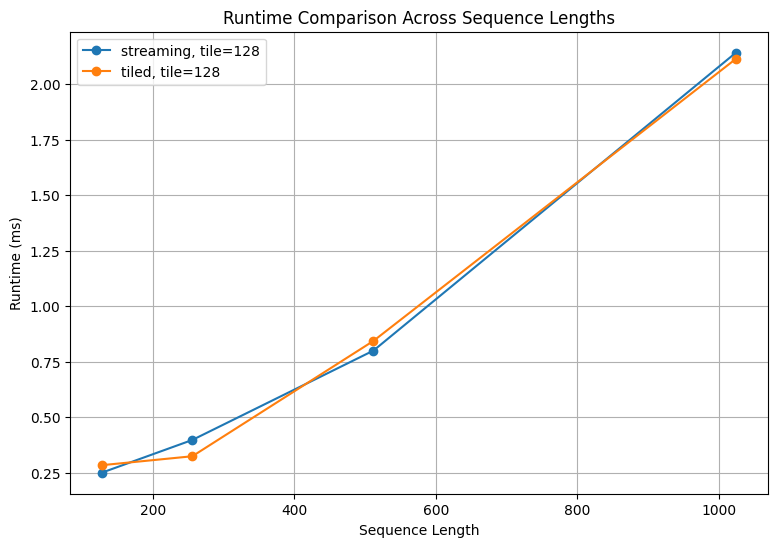

In [ ]:
plot_df = results_df[
    (
        (results_df["implementation"] == "baseline")
        |
        (
            (results_df["implementation"] == "tiled")
            &
            (results_df["tile_size"] == 128)
        )
        |
        (
            (results_df["implementation"] == "streaming")
            &
            (results_df["tile_size"] == 128)
        )
    )
    &
    (results_df["batch_size"] == 1)
]

plt.figure(figsize=(9, 6))

for label, group in plot_df.groupby(
    ["implementation", "tile_size"]
):

    implementation, tile_size = label

    if pd.isna(tile_size):
        plot_label = implementation
    else:
        plot_label = f"{implementation}, tile={int(tile_size)}"

    plt.plot(
        group["seq_len"],
        group["runtime_ms"],
        marker="o",
        label=plot_label
    )

plt.xlabel("Sequence Length")
plt.ylabel("Runtime (ms)")
plt.title("Runtime Comparison Across Sequence Lengths")

plt.legend()

plt.grid(True)

plt.show()

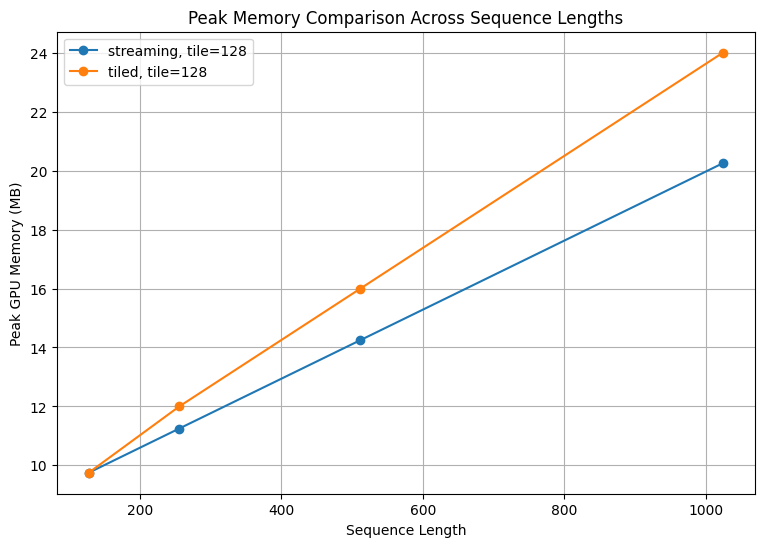

In [ ]:
if results_df["peak_memory_mb"].notna().any():

    plot_df = results_df[
        (
            (results_df["implementation"] == "baseline")
            |
            (
                (results_df["implementation"] == "tiled")
                &
                (results_df["tile_size"] == 128)
            )
            |
            (
                (results_df["implementation"] == "streaming")
                &
                (results_df["tile_size"] == 128)
            )
        )
        &
        (results_df["batch_size"] == 1)
    ]

    plt.figure(figsize=(9, 6))

    for label, group in plot_df.groupby(
        ["implementation", "tile_size"]
    ):

        implementation, tile_size = label

        if pd.isna(tile_size):
            plot_label = implementation
        else:
            plot_label = f"{implementation}, tile={int(tile_size)}"

        plt.plot(
            group["seq_len"],
            group["peak_memory_mb"],
            marker="o",
            label=plot_label
        )

    plt.xlabel("Sequence Length")

    plt.ylabel("Peak GPU Memory (MB)")

    plt.title("Peak Memory Comparison Across Sequence Lengths")

    plt.legend()

    plt.grid(True)

    plt.show()

else:
    print("GPU memory measurements unavailable.")

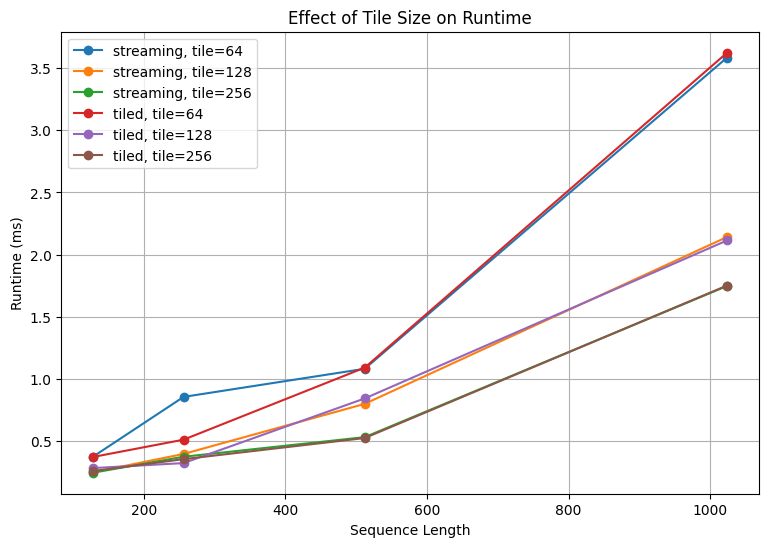

In [ ]:
tile_runtime_df = results_df[
    (
        (results_df["implementation"] == "tiled")
        |
        (results_df["implementation"] == "streaming")
    )
    &
    (results_df["batch_size"] == 1)
]

plt.figure(figsize=(9, 6))

for label, group in tile_runtime_df.groupby(
    ["implementation", "tile_size"]
):

    implementation, tile_size = label

    plt.plot(
        group["seq_len"],
        group["runtime_ms"],
        marker="o",
        label=f"{implementation}, tile={int(tile_size)}"
    )

plt.xlabel("Sequence Length")

plt.ylabel("Runtime (ms)")

plt.title("Effect of Tile Size on Runtime")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
summary_df = results_df.groupby(
    "implementation"
).agg(
    avg_runtime_ms=("runtime_ms", "mean"),
    max_runtime_ms=("runtime_ms", "max"),
    avg_peak_memory_mb=("peak_memory_mb", "mean"),
    max_peak_memory_mb=("peak_memory_mb", "max"),
    max_correctness_error=("max_abs_error", "max")
).reset_index()

summary_df

,implementation,avg_runtime_ms,max_runtime_ms,avg_peak_memory_mb,max_peak_memory_mb,max_correctness_error
0,baseline,0.663341,1.789160,28.937500,85.125,0.0
1,dsl_baseline,0.621212,1.782031,28.937500,85.125,0.0
2,streaming,1.246869,5.615041,17.088542,40.625,0.0
3,tiled,1.212596,5.526149,19.567708,55.625,0.0


In [ ]:
results_df.to_csv(
    "week5_attention_results.csv",
    index=False
)

summary_df.to_csv(
    "week5_attention_summary.csv",
    index=False
)

print("Saved CSV files:")
print("week5_attention_results.csv")
print("week5_attention_summary.csv")

Saved CSV files:
week5_attention_results.csv
week5_attention_summary.csv


In [ ]:
from google.colab import files

files.download("week5_attention_results.csv")
files.download("week5_attention_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Week 5 Summary

This notebook evaluated multiple attention execution strategies developed during
Weeks 1–4 of the project, including:

1. Baseline scaled dot-product attention  
2. DSL baseline execution  
3. Tiled attention transformation  
4. Streaming tiled attention transformation  

The experiments measured:

- Runtime performance
- Peak GPU memory usage
- Numerical correctness
- Scalability across sequence lengths

The tiled and streaming implementations preserved exact attention semantics while
reducing intermediate memory pressure through block-wise execution patterns.

Although the current prototype uses high-level PyTorch tensor operations rather than
custom CUDA kernels, the results demonstrate that compiler-style transformations can
expose memory-efficient execution strategies through a programmable, domain-specific
abstraction.

The benchmark tables and figures generated in this notebook will support the
Experimental Setup, Results, Discussion, and Conclusion sections of the final report.